# Mallinnus

Vertailen logistista regressiota kaikilla 30 muuttujalla sekä logistista regressiota ja Random Forestia L1-valituilla muuttujilla. Päävertailu on kahden jälkimmäisen välillä; käytän Stage 1:n 75/25-jakoa ja testidataa vasta lopulliseen arviointiin.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
C_VALUES = [0.01, 0.1, 1, 10]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

## Datan lataaminen

Kohdemuuttuja `malignant`: 0 = hyvänlaatuinen, 1 = pahanlaatuinen.

In [2]:
DATA_PATH = Path("data")
if not DATA_PATH.exists():
    DATA_PATH = Path("Breast_cancer_project") / "data"

training = pd.read_csv(DATA_PATH / "training_dataset.csv")
test = pd.read_csv(DATA_PATH / "test_dataset.csv")

X_train = training.drop(columns="malignant")
y_train = training["malignant"]
X_test = test.drop(columns="malignant")
y_test = test["malignant"]

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

class_counts = pd.DataFrame({
    "Training": y_train.value_counts(),
    "Test": y_test.value_counts(),
}).sort_index().rename(index={0: "Benign", 1: "Malignant"})
display(class_counts)

Training shape: (426, 30)
Test shape: (143, 30)


,Training,Test
malignant,,
Benign,267,90
Malignant,159,53


## Logistinen regressio kaikilla muuttujilla

Standardoin muuttujat Pipelinen sisällä niiden eri mittakaavojen vuoksi. Valitsen `C`:n viisikertaisella ositetulla ristiinvalidoinnilla käyttäen ROC-AUC:ta.

In [3]:
all_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_SEED)),
])

all_search = GridSearchCV(
    all_logistic,
    {"model__C": C_VALUES},
    scoring="roc_auc",
    cv=cv,
    n_jobs=2,
    error_score="raise",
)
all_search.fit(X_train, y_train)

print("Best parameters:", all_search.best_params_)
print("CV ROC-AUC:", round(all_search.best_score_, 3))

Best parameters: {'model__C': 0.1}
CV ROC-AUC: 0.992


## Muuttujien valinta

L1 voi nollata kertoimia; valitsen mukaan vain muuttujat, joiden kerroin poikkeaa nollasta. Stage 1:ssä radius-, perimeter- ja area-muuttujat sekä vastaavat mean/worst-muuttujat korreloivat voimakkaasti.

In [4]:
l1_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=5000,
        random_state=RANDOM_SEED,
    )),
])

l1_search = GridSearchCV(
    l1_logistic,
    {"model__C": C_VALUES},
    scoring="roc_auc",
    cv=cv,
    error_score="raise",
)
l1_search.fit(X_train, y_train)

coefficients = l1_search.best_estimator_.named_steps["model"].coef_[0]
selected_features = X_train.columns[coefficients != 0]

feature_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": coefficients,
    "Absolute coefficient": np.abs(coefficients),
})
feature_table = feature_table[feature_table["Coefficient"] != 0]
feature_table = feature_table.sort_values("Absolute coefficient", ascending=False)

print("Best parameters:", l1_search.best_params_)
print("Selected features:", len(selected_features))
display(feature_table.round(3).reset_index(drop=True))

Best parameters: {'model__C': 1}
Selected features: 15


,Feature,Coefficient,Absolute coefficient
0,radius error,2.759,2.759
1,worst area,2.271,2.271
2,worst texture,2.052,2.052
3,mean concave points,1.969,1.969
4,worst radius,1.174,1.174
5,worst concavity,1.087,1.087
6,compactness error,-1.047,1.047
7,texture error,-0.720,0.720
8,worst symmetry,0.602,0.602
9,smoothness error,0.393,0.393


Sovitan L1-mallin skaalauksen, `C`-haun ja muuttujavalinnan kunkin ristiinvalidointikierroksen opetusosaan. Lopullinen muuttujajoukko saadaan koko opetusdatasta.

In [5]:
feature_selector = SelectFromModel(
    clone(l1_search),
    # The smallest positive float excludes exact zero coefficients.
    threshold=np.nextafter(0.0, 1.0),
    importance_getter="best_estimator_.named_steps.model.coef_",
)

## Logistinen regressio valituilla muuttujilla

Sovitan valituille muuttujille erillisen L2-logistisen mallin. Pipeline huolehtii muuttujavalinnasta ja skaalauksesta, ja valitsen `C`:n ristiinvalidoinnilla.

In [6]:
selected_logistic = Pipeline([
    ("selection", clone(feature_selector)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_SEED)),
])

selected_search = GridSearchCV(
    selected_logistic,
    {"model__C": C_VALUES},
    scoring="roc_auc",
    cv=cv,
    n_jobs=2,
    error_score="raise",
)
selected_search.fit(X_train, y_train)

print("Best parameters:", selected_search.best_params_)
print("CV ROC-AUC:", round(selected_search.best_score_, 3))

Best parameters: {'model__C': 1}
CV ROC-AUC: 0.989


## Random Forest

Random Forest käyttää samoja L1-valittuja muuttujia ilman skaalausta. Puita on 200, ja valitsen syvyyden ja lehden vähimmäiskoon neljästä yhdistelmästä ROC-AUC:n perusteella.

In [7]:
forest = Pipeline([
    ("selection", clone(feature_selector)),
    ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED)),
])

forest_search = GridSearchCV(
    forest,
    {
        "model__max_depth": [None, 5],
        "model__min_samples_leaf": [1, 2],
    },
    scoring="roc_auc",
    cv=cv,
    n_jobs=2,
    error_score="raise",
)
forest_search.fit(X_train, y_train)

print("Best parameters:", forest_search.best_params_)
print("CV ROC-AUC:", round(forest_search.best_score_, 3))

selected_logistic_features = X_train.columns[
    selected_search.best_estimator_.named_steps["selection"].get_support()
]
forest_features = X_train.columns[
    forest_search.best_estimator_.named_steps["selection"].get_support()
]
assert selected_logistic_features.equals(selected_features)
assert forest_features.equals(selected_features)
print("Selected features used by both models:", len(selected_features))

Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1}
CV ROC-AUC: 0.989
Selected features used by both models: 15


## Päätöskynnyksen valinta

Valitsen kullekin mallille kynnyksen opetusdatan out-of-fold-ennusteista Youdenin J:llä (herkkyys + spesifisyys − 1). Muuttujavalinta ja parametrien haku toistetaan kierrosten opetusosissa. Testidataa ei käytetä kynnyksen valintaan, jotta loppuarvio säilyy riippumattomana.

In [8]:
model_searches = {
    "Logistic regression - all features": all_search,
    "Logistic regression - selected features": selected_search,
    "Random Forest - selected features": forest_search,
}
thresholds = {}

for name, search in model_searches.items():
    oof_probabilities = cross_val_predict(
        clone(search),
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
    )[:, 1]

    false_positive_rate, sensitivity, candidates = roc_curve(
        y_train, oof_probabilities, drop_intermediate=False
    )
    youden_j = sensitivity - false_positive_rate
    finite_indices = np.flatnonzero(np.isfinite(candidates))
    best_index = finite_indices[np.argmax(youden_j[finite_indices])]
    thresholds[name] = candidates[best_index]
    print(name, "threshold:", round(thresholds[name], 3))

Logistic regression - all features threshold: 0.384


Logistic regression - selected features threshold: 0.433


Random Forest - selected features threshold: 0.465


## Lopullinen arviointi

Arvioin mallit testidatalla vasta kaikkien valintojen jälkeen. Herkkyys kuvaa pahanlaatuisten tapausten tunnistamista, ja spesifisyys on TN / (TN + FP). ROC-AUC lasketaan todennäköisyyksistä ja muut mittarit valituilla kynnyksillä.

In [9]:
comparison_rows = []
test_probabilities = {}

for name, search in model_searches.items():
    model = search.best_estimator_
    probabilities = model.predict_proba(X_test)[:, 1]
    test_probabilities[name] = probabilities
    predictions = (probabilities >= thresholds[name]).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, predictions, labels=[0, 1]).ravel()
    feature_count = model.named_steps["model"].n_features_in_

    comparison_rows.append({
        "Model": name,
        "Number of features": feature_count,
        "Threshold": thresholds[name],
        "Sensitivity": tp / (tp + fn),
        "Specificity": tn / (tn + fp),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "Accuracy": accuracy_score(y_test, predictions),
    })

comparison = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison.round(3))

,Number of features,Threshold,Sensitivity,Specificity,ROC-AUC,Accuracy
Model,,,,,,
Logistic regression - all features,30,0.384,0.981,1.000,0.998,0.993
Logistic regression - selected features,15,0.433,0.943,0.989,0.998,0.972
Random Forest - selected features,15,0.465,0.925,1.000,0.997,0.972


## ROC-käyrät

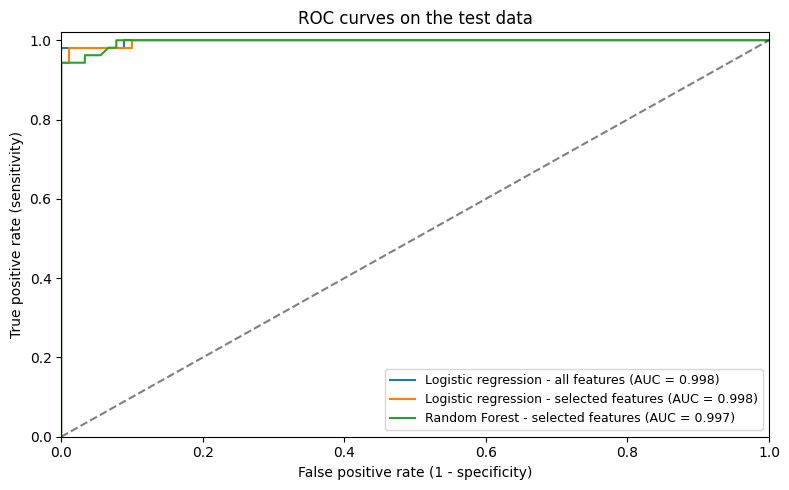

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

for name, probabilities in test_probabilities.items():
    false_positive_rate, sensitivity, _ = roc_curve(y_test, probabilities)
    auc = comparison.loc[name, "ROC-AUC"]
    ax.plot(false_positive_rate, sensitivity, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set(
    xlabel="False positive rate (1 - specificity)",
    ylabel="True positive rate (sensitivity)",
    title="ROC curves on the test data",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## Mallien vertailu

L1-valinta pienensi muuttujamäärän 30:stä 15:een. Logistisen regression ROC-AUC pysyi pyöristettynä samana (0,998; laskua noin 0,0006), mutta herkkyys laski 0,981:stä 0,943:een ja spesifisyys 1,000:sta 0,989:ään. Muuttujien vähentäminen säilytti siis erottelukyvyn lähes ennallaan, mutta heikensi luokittelutulosta valituilla kynnyksillä.

Päävertailussa Random Forestin ROC-AUC oli 0,997 ja pienemmän logistisen mallin 0,998. Metsän herkkyys oli matalampi (0,925 vs. 0,943), mutta spesifisyys korkeampi (1,000 vs. 0,989). Molempien tarkkuus oli 0,972. Random Forest ei tuonut selvää parannusta pienempään logistiseen malliin verrattuna.

Yksinkertaisempi 15 muuttujan logistinen malli oli kilpailukykyinen Random Forestiin nähden. Täysi logistinen malli sai tässä testijoukossa parhaat tulokset. Testijoukossa oli 143 havaintoa, joista 53 pahanlaatuisia, joten pienistä eroista ei voi päätellä mallien yleistä paremmuutta.
